In [39]:
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import re
import numpy as np
import matplotlib.pyplot as plt
import powerlaw
from collections import Counter

# Carregamento e Limpeza dos Dados

In [40]:
# Carregar a base de dados
# O MoMA possui um dataset chamado 'Artworks.csv'
df = pd.read_csv(r'../data/Artworks.csv')

In [41]:
# Filtrar apenas obras de arte visuais (Pinturas)
df_paintings = df[df['Classification'] == 'Painting'].copy()

In [42]:
# Limpeza das Datas (O dataset do MoMA tem datas como "c. 1914" ou "1915-16")
# Utilizar uma expressão regular simples para capturar o primeiro bloco de 4 números
def extract_year(date_str):
    if pd.isna(date_str):
        return None
    match = re.search(r'(\d{4})', str(date_str))
    if match:
        return int(match.group(1))
    return None

In [43]:
df_paintings['Year'] = df_paintings['Date'].apply(extract_year)

In [44]:
# Remover linhas onde não conseguimos extrair o ano ou não há artista
df_paintings = df_paintings.dropna(subset=['Artist', 'Year'])

In [45]:
# Visualizar como ficou o dado limpo
print(df_paintings[['Artist', 'Year']].head())

              Artist    Year
31990      Joan Miró  1935.0
33074      Paul Klee  1929.0
33331      Paul Klee  1927.0
34391  Pablo Picasso  1919.0
35310    Arthur Dove  1925.0


# Criação do Grafo Bipartido

In [46]:
B = nx.Graph()

# Separar as duas classes de nós (Pintores e Anos)
# Usamos set() para garantir que sejam únicos
artists = set(df_paintings['Artist'])
years = set(df_paintings['Year'])

# Adicionar nós ao grafo com o atributo 'bipartite'
B.add_nodes_from(artists, bipartite=0) # Classe 0: Pintores
B.add_nodes_from(years, bipartite=1)   # Classe 1: Anos

# Criar as arestas (Pintor -> Ano)
# Se o pintor fez 5 quadros em 1910, queremos apenas 1 aresta (Pintor, 1910)
# Para isso, removemos as duplicatas
artist_year_pairs = df_paintings[['Artist', 'Year']].drop_duplicates()
edges = list(artist_year_pairs.itertuples(index=False, name=None))

B.add_edges_from(edges)

print(f"Nós (Pintores): {len(artists)}")
print(f"Nós (Anos): {len(years)}")
print(f"Arestas (Pintor -> Ano): {B.number_of_edges()}")

Nós (Pintores): 1083
Nós (Anos): 145
Arestas (Pintor -> Ano): 2040


# Projeção Ponderada e Filtragem

In [47]:
# O NetworkX calcula automaticamente o peso baseado nos vizinhos em comum (neste caso, os anos)
artist_network = bipartite.weighted_projected_graph(B, artists)

print(f"Rede de Pintores criada com {artist_network.number_of_nodes()} nós e {artist_network.number_of_edges()} arestas.")

# Filtragem de Ruído (Threshold)
# Se Picasso e Braque produziram no mesmo ano apenas 1 vez na vida, a conexão é fraca.
# Vamos manter apenas arestas de pintores que coincidiram em pelo menos 3 anos diferentes.
peso_minimo = 3
arestas_fortes = [(u, v, d) for u, v, d in artist_network.edges(data=True) if d['weight'] >= peso_minimo]

# Criar um novo grafo apenas com as arestas fortes
G_filtrado = nx.Graph()
G_filtrado.add_edges_from(arestas_fortes)

# Extrair a Maior Componente Conexa (Giant Component)
componentes = sorted(nx.connected_components(G_filtrado), key=len, reverse=True)
G_principal = G_filtrado.subgraph(componentes[0]).copy()

print(f"Rede Final (Pintores fortemente conectados): {G_principal.number_of_nodes()} nós e {G_principal.number_of_edges()} arestas.")

Rede de Pintores criada com 1083 nós e 20561 arestas.
Rede Final (Pintores fortemente conectados): 105 nós e 236 arestas.


# Métricas Topológicas Básicas e Centralidades

In [48]:
# Métricas Globais da Rede
nnodes = G_principal.number_of_nodes()
nedges = G_principal.number_of_edges()
density = nx.density(G_principal)
avg_clustering = nx.average_clustering(G_principal)

graus = dict(G_principal.degree())
avg_degree = sum(graus.values()) / nnodes

print("--- Métricas Globais ---")
print(f"Nós: {nnodes}")
print(f"Arestas: {nedges}")
print(f"Densidade: {density:.4f}")
print(f"Grau Médio: {avg_degree:.2f}")
print(f"Coeficiente de Aglomeração Médio: {avg_clustering:.4f}")

--- Métricas Globais ---
Nós: 105
Arestas: 236
Densidade: 0.0432
Grau Médio: 4.50
Coeficiente de Aglomeração Médio: 0.4914


In [49]:
# Métricas Locais (Centralidades)
# Degree Centrality: Fração de nós aos quais um pintor está conectado (popularidade)
deg_centrality = nx.degree_centrality(G_principal)

# Betweenness Centrality: Quantas vezes o pintor atua como ponte nos caminhos mais curtos (interseção de movimentos)
bet_centrality = nx.betweenness_centrality(G_principal)

# Eigenvector Centrality: Conexão a outros pintores bem conectados (influência de elite)
eig_centrality = nx.eigenvector_centrality(G_principal, max_iter=1000)

# Criar um DataFrame para facilitar a análise dos artistas
df_metrics = pd.DataFrame({
    'Grau': graus,
    'Degree Centrality': deg_centrality,
    'Betweenness Centrality': bet_centrality,
    'Eigenvector Centrality': eig_centrality
})

# Visualizar os 10 artistas com maior grau
display(df_metrics.sort_values(by='Grau', ascending=False).head(10))

,Grau,Degree Centrality,Betweenness Centrality,Eigenvector Centrality
Pablo Picasso,42,0.403846,0.601013,0.481204
Jean Dubuffet,24,0.230769,0.349433,0.260304
Roy Lichtenstein,17,0.163462,0.202985,0.091480
Philip Guston,16,0.153846,0.238616,0.193027
Joan Miró,14,0.134615,0.044502,0.194503
Paul Klee,14,0.134615,0.075552,0.155135
Jackson Pollock,14,0.134615,0.093137,0.181165
Henri Matisse,13,0.125000,0.005717,0.208715
Andy Warhol,13,0.125000,0.088189,0.133368
Jasper Johns,12,0.115385,0.053985,0.145820


# Distribuição de Grau e Ajuste da Função

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 14/14 [00:00<00:00, 338.77it/s]


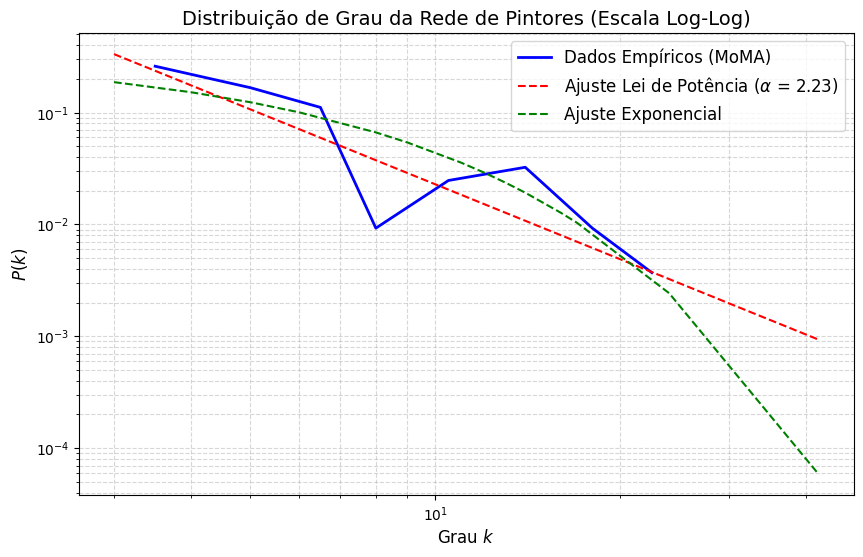

In [50]:
# Extrair apenas os valores de grau da rede
lista_graus = list(graus.values())

# Realizar o ajuste estatístico para dados discretos (pois grau é um número inteiro)
fit = powerlaw.Fit(lista_graus, discrete=True)

# Plotagem
plt.figure(figsize=(10, 6))

# Plota os dados empíricos (PDF - Função de Densidade de Probabilidade)
fit.plot_pdf(color='b', linewidth=2, label='Dados Empíricos (MoMA)')

# Plota o ajuste teórico da Lei de Potência
fit.power_law.plot_pdf(color='r', linestyle='--', label=f'Ajuste Lei de Potência ($\\alpha$ = {fit.power_law.alpha:.2f})')

# Plota um ajuste exponencial para comparação visual
fit.exponential.plot_pdf(color='g', linestyle='--', label='Ajuste Exponencial')

plt.title('Distribuição de Grau da Rede de Pintores (Escala Log-Log)', fontsize=14)
plt.xlabel('Grau $k$', fontsize=12)
plt.ylabel('$P(k)$', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [51]:
# Teste Estatístico (Log-Likelihood Ratio Test)
# Compara a Lei de Potência contra a Exponencial
R, p_value = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)

print("\n--- Teste de Ajuste de Distribuição ---")
print(f"Expoente da Lei de Potência (alpha): {fit.power_law.alpha:.3f}")
print(f"X mínimo (a partir de onde a lei se aplica): {fit.power_law.xmin}")
print(f"Razão de Verossimilhança (R): {R:.3f}")
print(f"Valor-p: {p_value:.3e}")

# Interpretação:
# Se R > 0 e o valor-p for baixo (< 0.05), a Lei de Potência explica melhor os dados do que a Exponencial.


--- Teste de Ajuste de Distribuição ---
Expoente da Lei de Potência (alpha): 2.226
X mínimo (a partir de onde a lei se aplica): 3.0
Razão de Verossimilhança (R): 0.241
Valor-p: 8.092e-01


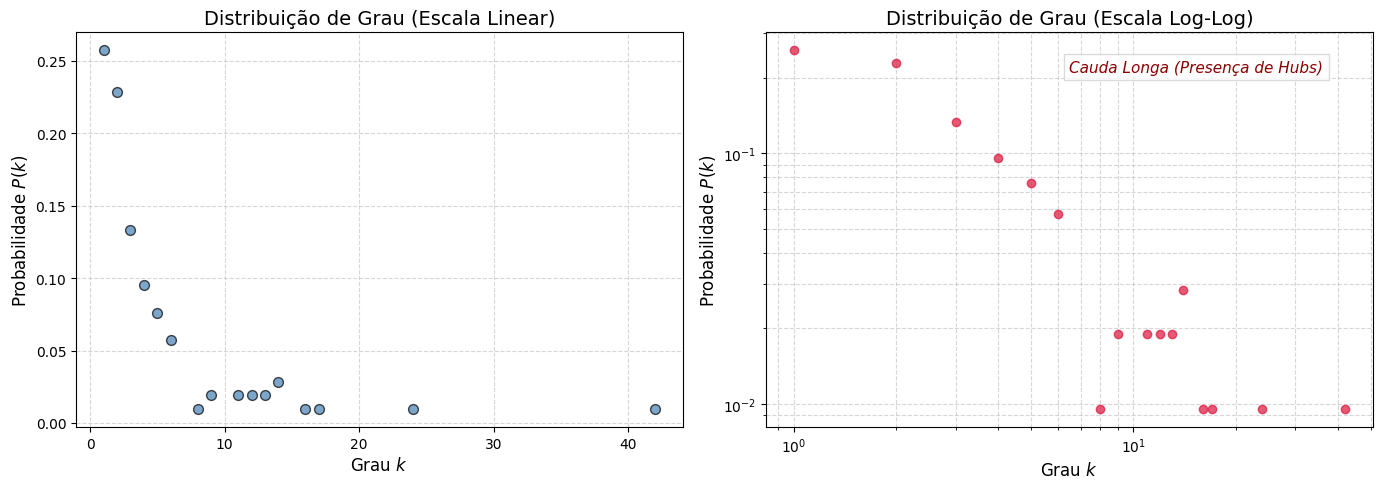

In [52]:
# Extração dos graus da rede
# Pegamos a lista com o grau de cada pintor na componente principal
graus = [grau for no, grau in G_principal.degree()]
numero_de_nos = G_principal.number_of_nodes()

# Cálculo da Probabilidade P(k)
# Conta quantas vezes cada grau k aparece na rede
contagem_graus = Counter(graus)

# Separa as chaves (grau k) e os valores (frequência do grau k)
k_valores = list(contagem_graus.keys())

# P(k) é a frequência do grau k dividida pelo total de nós
Pk_valores = [frequencia / numero_de_nos for frequencia in contagem_graus.values()]

# Configuração da Figura (Painel duplo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Escala Linear ---
ax1.scatter(k_valores, Pk_valores, color='steelblue', alpha=0.7, edgecolors='black', s=50)
ax1.set_title('Distribuição de Grau (Escala Linear)', fontsize=14)
ax1.set_xlabel('Grau $k$', fontsize=12)
ax1.set_ylabel('Probabilidade $P(k)$', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: Escala Log-Log (A visão Clássica) ---
ax2.loglog(k_valores, Pk_valores, 'o', color='crimson', alpha=0.7)
ax2.set_title('Distribuição de Grau (Escala Log-Log)', fontsize=14)
ax2.set_xlabel('Grau $k$', fontsize=12)
ax2.set_ylabel('Probabilidade $P(k)$', fontsize=12)
ax2.grid(True, which="both", linestyle='--', alpha=0.5)

# Adicionando um texto explicativo no gráfico log-log
ax2.text(0.5, 0.9, 'Cauda Longa (Presença de Hubs)', transform=ax2.transAxes, 
         fontsize=11, color='darkred', style='italic',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))

# Ajuste fino do layout
plt.tight_layout()
plt.show()